# Chapter 3 | Classification: MNIST handwritten digits recognition

## Data

sklearn.datasets package contains mostly 3 types of functions:
- fetch_* to download real-life datasets;
- load_* to load small toy datasets;
- make_* to generate fake datasets.

Last ones are usually returned as an (X, y) tuple, in which X and y are both NumPy arrays, while the first two return sklearn.utils.Bunch objects, which are dictionaries that generally contains:
- 'DESCR' - description;
- 'data' - the input data, usually as 2D NumPy array;
- 'target' - the labels, usually as 1D NumPy array.

We will use the fetch_openml() function, which is a bit unusual since it returns input as Pandas DataFrame and labels as Pandas Series, but since we're working with images, DataFrames are not ideal, so we will set as_frame = False to get a NumPy array:

In [9]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame = False)

In [6]:
X, y = mnist.data, mnist.target
X, y

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
 array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object))

In [7]:
X.shape, y.shape

((70000, 784), (70000,))

We got 70k images, each with 784 features (these are the 28x28 pixels, so each feature is the pixel's intensity from 0 white to 255 black). 

Let's define a function which plots the image:
- reshape the 256 features in a 28x28 array;
- show the image with plt.imshow (cmap = 'binary' get a grayscale colormap)

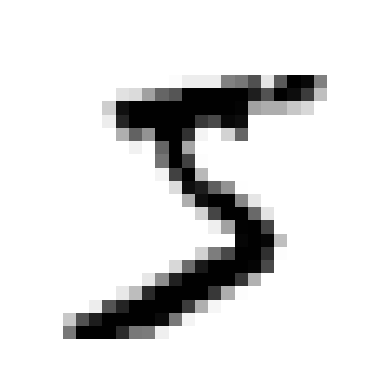

In [10]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap = 'binary')
    plt.axis('off') #remove axis
    plt.show()
    
plot_digit(X[0])

This looks like a 5; let's check the label:

In [9]:
y[0]

'5'

## Train-Test Split
The MNIST dataset is already split into training set (first 60k images) and test set (last 10k images), so we don't need to perform a random split:

In [11]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Binary Classifier
It is the easiest classifier, which needs to solve the task of distinguishing between just 2 classes. In our case, let's focus on building a Binary Classifier which identify just one digit, for example the number 5: the 2 classes are 5 and non-5.

Let's create the target vectors for this classification task:

In [12]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

We will start by training a Stochastic Gradient Descent (SGD), which is a classifier capable of handling very large datasets efficiently:

In [13]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


Let's use it to predict the first observation, which was a 5:

In [14]:
sgd_clf.predict([X[0]])

array([ True])

It guessed right! Let's evaluate this model's performance:

### Performance Measures
Evaluating a classifier is often significantly trickier than evaluating a regressor because there are many performance measures available.

#### Accuracy
As we did for regression, we can use Cross-Validation and this time we would get different Accuracy scores (i.e., ratio of correct predictions); this time the function to use is cross_val_score:

In [15]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring = 'accuracy')

array([0.95035, 0.96035, 0.9604 ])

We got above 95% accuracy! Should we be amazed? Before getting to excited, let's look at a dummy classifier which classifies every single image in the most frequent class (in this case the negative class non-5):

In [16]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
cross_val_score(dummy_clf, X_train, y_train_5, cv = 3, scoring = 'accuracy')

array([0.90965, 0.90965, 0.90965])

We got over 90% accuracy: this is simply because only around 10% of images are 5s, so even a dummy classifier would seem to perform well.

This is proof that accuracy is not the preferred performance measure for classifiers, especially with skewed/unbalanced datasets.

What we should look at instead is the Confusion Matrix (CM):

#### Confusion Matrix
The general idea is to count the number of times instances of class A are classified as class B, for each A/B pair.

Let's first compute the prediction, using the *cross_val_predict()* function (this function splits the data into *cv* folds, fit the classifier on all folds except one and make predictions for this last fold, then it repeats this process excluding each time 1 different fold and combines the predictions obtaining predictions for every observation):

In [17]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

We can then easily compute the Confusion Matrix with the confusion_matrix function:

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In a confusion matrix:
- each ROW represents an Actual Class;
- each COLUMN represents a Predicted Class.

The confusion matrix is in the form:

$$
\begin{bmatrix}
    TN & FP \\
    FN & TP
\end{bmatrix}
$$

where: 
- TN = True Negatives: correctly predicted Negatives.
- FP = False Positives: incorrectly predicted Positives (or Type I error).
- FN = False Negatives: incorrectly predicted Negatives (or Type II error).
- TP = True Positives: correctly predicted Positives.

A perfect classifier would only have values on the main diagonal (top left to bottom right).

From the Confusion Matrix we can compute a lot of other metrics:

##### Precision and Recall

- precision = $\frac{TP}{TP+FP}$ -> is the accuracy of the positive predictions (how many of the ones we predicted as positives are real positives); (generally used among the recall);

- recall = sensitivity = TPR = $\frac{TP}{TP+FN}$ -> is the true positive rate (how many positive we predicted correctly over all the positives); (generally used among the precision);

In [20]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred), recall_score(y_train_5, y_train_pred)

(0.8370879772350012, 0.6511713705958311)

We interpret these as:
- precision of 83.7% -> when our classifier predict an image as 5, it is correct 83.7% of times;
- recall of 65.1% -> our classifier detects the 65.1% of 5s.

It is convenient to combine precision and recall into a single metric, called $F_1 score$, which is the harmonic mean of both:
$$ F_1 = 2* \frac{Precision*Recall}{Precision + Recall}$$

In [21]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343847

NOTE: $F_1$ score tends to prefer classifiers having similar precision and recall, but sometimes this is not what we want: in some contexts we could care more about precision, while in other about recall; examples:
- video for kid detector -> it is better if it rejects many good videos (low recall) rather than not rejecting many bad ones (high precision);
- detecting shop thefts from cameras -> it is better if it spots some false thefts (high recall) rather than not spotting some real thefts (low precision).

Unfortunately, we can't increase both: this is known as Precision/Recall Trade-off: algorithms will use a threshold to assign instances to positive or negative class; we can't change these treshold directly in sklearn, but we can access the Decision Scores assigned by the algorithm (the ones that will then be compared to the treshold to assign a class) and manually compare them to a custom threshold.

We know that SGDClassifier uses a threshold of 0, so doing the sequent code returns the same as using predict():

In [22]:
y_scores = sgd_clf.decision_function([X[0]])
y_scores

array([2164.22030239])

In [23]:
threshold = 0
y_x0_pred = (y_scores > threshold)
y_x0_pred

array([ True])

Let's try to change the threshold:

In [24]:
threshold = 3000
y_x0_pred = (y_scores > threshold)
y_x0_pred

array([False])

This proofs that increasing the threshold will decrease the recall (cause the 5 is no more recognised). So, how do we choose the threshold?

First we use cross_val_predict, but this time we don't want the predictions, but the decision scores:

In [25]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3, method = 'decision_function')

Then, we use the precision_recall_curve() method to compute precision and recall for all possible thresholds:

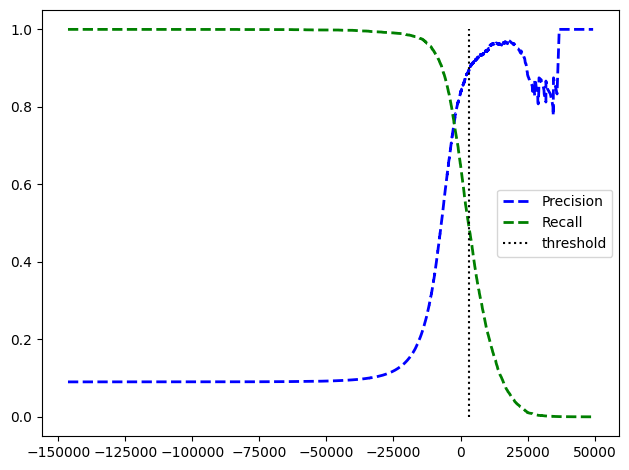

In [26]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.plot(thresholds, precisions[:-1], 'b--', label = 'Precision', linewidth = 2)
plt.plot(thresholds, recalls[:-1], 'g--', label = 'Recall', linewidth = 2)
plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label = 'threshold')
plt.legend()
plt.tight_layout()
plt.show()

Another way of selecting the threshold is by plotting precision against recall:

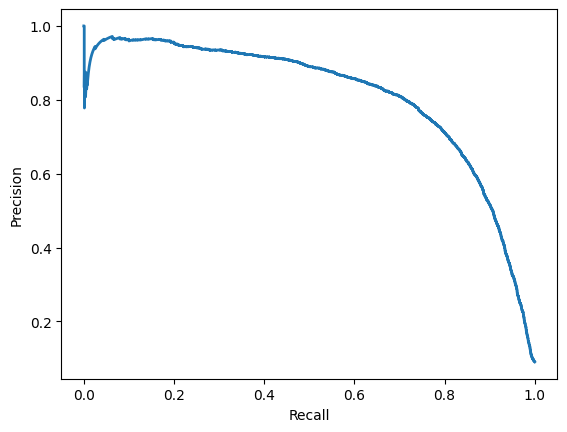

In [27]:
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

Once we decided which precision/recall we're aiming for our project, we can get the lowest threshold that gives that precision/recall with NumPy argmax() method; suppose we aim for a precision of 90%:

In [28]:
idx_for_90_precision = (precisions >= 0.9).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

Now, instead of calling .predict() to make predictions, we run the code as before:

In [29]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

Let's compute precision and recall:

In [30]:
precision_score(y_train_5, y_train_pred_90), recall_score(y_train_5, y_train_pred_90)

(0.9000345901072293, 0.4799852425751706)

We obtained a 90% precision classifier (note that recall is 48%, which is commonly low, so this classifier is not very reliable).

#### ROC (Receiving Operating Characteristic) Curve
The **ROC** is another common tool for **binary classifiers**: it plots the **Recall** (or **TPR**) against the **Fall-Out** (or **FPR**).

The **FPR** is equal to 1- **TNR**; the **TNR** is also called **specificity**, while the **FPR** is also called **sensitivity**.

So the ROC Curve plots the Recall/TPR against the Fall-Out/FPR/1-specificity.

To plot it, we first use *roc_curve()* to compute **TPR** and **FPR** for various threshold values:

In [31]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

We can then plot the FPR against the TPR (we also plot the point corresponding to 90% precision):

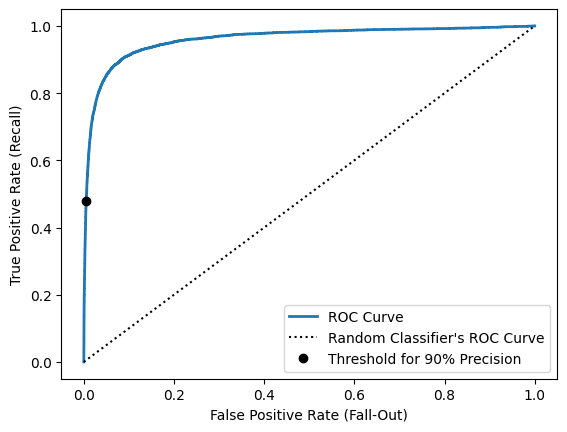

In [36]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label = "ROC Curve")
plt.plot([0, 1], [0, 1], 'k:', label = "Random Classifier's ROC Curve")
plt.plot([fpr_90], [tpr_90], 'ko', label = "Threshold for 90% Precision")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

Once again, we can see there's a **trade-off**, this time between Recall (TPR) and Fall-Out(FPR); considering the dotted line is a Random Classifier's ROC Curve, a good classifier stays far away from that line as possible (so, toward the top-left corner).

One way to compare classifiers is by measuring the **Area Under the Curve (AUC)**:
- perfect classifier -> AUC = 1;
- random classifier -> AUC = 0.5

We can estimate the ROC AUC with sklearn:

In [38]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

0.9604938554008616

So, when should you use ROC curve and when should you use the PR (Precision/Recall) curve?
- PR Curve: when positive class is rare or you care more about false positives than false negatives;
- ROC Curve: otherwise.

Let's now create a RandomForestClassifier to compare to the SGDClassifier:

In [40]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

RandomForestClassifier has a *predict_proba()* method returning the class probabilities for each instance, so we'll make it predict class probabilities for every image as follow:

In [42]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method='predict_proba')
y_probas_forest[:2] # probas for first 2 images

array([[0.11, 0.89],
       [0.99, 0.01]])

Model predicts that:
- first image is positive (it's 5) with 89%;
- second image is negative (it's not a 5) with 99%.

(sklearn.calibration package contains tools to calibrate the estimated probabilities)

Considering the second column contains estimated prob for positive class, we pass them to the *precision_recall_curve()*:

In [44]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

We can now plot the PR curve (we'll plot previous one aswell for comparison):

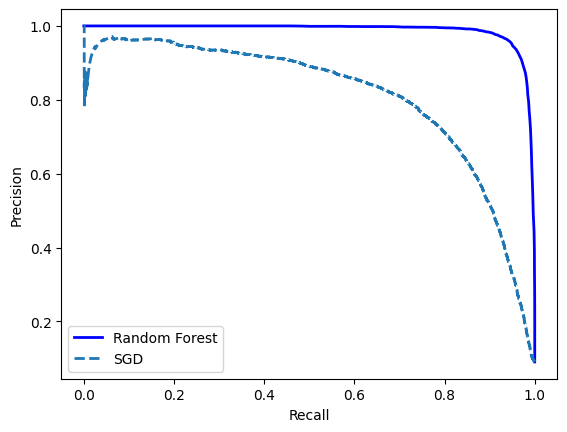

In [45]:
plt.plot(recalls_forest, precisions_forest, 'b-', linewidth=2, label='Random Forest')
plt.plot(recalls, precisions, "--", linewidth = 2, label = 'SGD')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

Random Forest's PR curve is better.

Let's now compare $F_1$ and ROC AUC:

In [50]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

Which is better than the $F_1 = 0.73$ we obtained with SGD.

In [51]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

Which is better than the $AUC = 0.96$ we obtained with SGD.

## Multiclass Classification
As the name suggests, it relies on building classifier which can distinguish between **more than 2 classes**.

Some sklearn classifiers are capable of handling multiple class natively (e.g., *LogisticRegression*, *RandomForestClassifier* and *GaussianNB*), while others are strictly binary classifiers (e.g., *SGDClassifier* and *SVC*).
However there are ways to use multiple binary classifiers to perform multiclass classification.

For example, for the above examples in which we are asked to classify the digit images into 10 classes (from 0 to 9) we could:

- **One-versus-the-REST (OvR)** or **One-versus-All (OvA)**: train 10 binary classifiers, one for each digit and assign each image to the class whose classifier outputs the highest score (generally better solution);
- **One-versus-One (OvO)**: train a binary classifier for every pair of digits (one to distinguish 0s and 1s, one to distinguish 0s and 2s, one to distinguish 1s and 2s, and so on); with $N$ classes, this takes to $N \times (N-1) / 2$ classifiers (in our case would mean 45 binary classifiers). The main advantage of this is the classifier needs to be trained only on the part of the training set containing the 2 classes it must distinguish (better for algorithms which scale poorly with the size of training set, such as support vector machine).

The good new about this is that sklearn automatically runs OvR or OvO depending on the algorithm.

Let's try a **Support Vector Machine Classifier (SVC)** training on only the first 2,000 images:

In [52]:
from sklearn.svm import SVC
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


(NOTE: sklearn used the OvO strategy training 45 binary classifiers)

Let's now make predictions on the same first image as before, which was a 5:

In [54]:
svm_clf.predict([X[0]])

array(['5'], dtype=object)

That's correct! We can also look at the scores it assigned to each class:

In [57]:
some_scores = svm_clf.decision_function([X[0]])
some_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

As we can see, the highest score is 9.3, which indeed corresponds to class 5:

In [58]:
class_id = some_scores.argmax()
class_id

np.int64(5)

When training a classifier, it stores the list of target classes in its classes_ attribute, ordered by value (in case of MNIST, index of each class matches the class itself, but in general thid doesn't happen):

In [59]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [60]:
svm_clf.classes_[class_id]

'5'

We can also force sklearn to use OvO or OvR by simply passing a classifier to its constructor:

In [61]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

,estimator,SVC(random_state=42)
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


In [62]:
ovr_clf.predict([X[0]])

array(['5'], dtype='<U1')

Let's now try to train an SGDClassifier and use it to predict that same observation:

In [65]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([X[0]])

array(['3'], dtype='<U1')

Ok, that's wrong. Let's use *decision_function()* to see what score has been assigned to each class (sklearn used OvR, so 10 scores are shown):

In [66]:
sgd_clf.decision_function([X[0]]).round()

array([[-31893., -34420.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

The classifier is not very confident about its prediction: all scores are negative, while class 3 has score of +1,824 and class 5 is not that far behind with -1,386. 

Of course, we can't evaluate a model just on one prediction; since number of images in each class is roughly balanced, we can use the accuracy metric to evaluate it:

In [67]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring='accuracy')

array([0.87365, 0.85835, 0.8689 ])

This classifier gets ober 85.8% on all 3 test folds (a random classifier would get 10% accuracy, so this is not that bad).

We can take accuracy above 89.1% just by scaling the inputs as discussed in Chapter 2:

In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype('float64'))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring='accuracy')

array([0.8983, 0.891 , 0.9018])

## Error Analysis
If this was a real project, we would now follow the steps in a ML project checklist (Appendix A):
- explore data preparation options;
- try multiple models;
- shortlist the best models;
- fine tune them with *GridSearchCV*.

Let's suppose we found a promising model and we want to improve it by analyzing the types of errors it makes by looking at the confusion matrix. By the way, having now 10 classes instead of 2, the confusion matrix will contain a lot of numbers and may be hard to read; we will then use a colored diagram of the confusion matrix using *ConfusionMatrixDisplay.from_prediction()*:

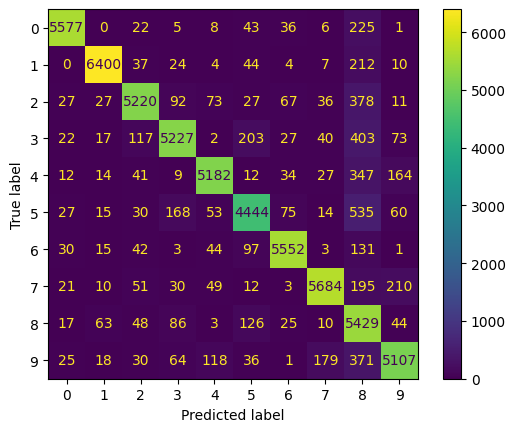

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

As we see, most images are on the main diagonal, meaning they have been classified correctly and so the model is pretty good. 

We can also see how the cell on the diagonal in row #5 and column #5 is darker and has a lower number than all the others: this could both means that the model made more errors on 5s, or that there are fewer 5s in the dataset than the other digits. That's why it is important to normalize the confusion matrix by dividing each value by the total number of images in the corresponding (true) class (i.e., by the row's sum). This can be done by putting *normalize = "true"* in the previous function; we can also put *values_format = ".0%"* to show percentages with no decimals:

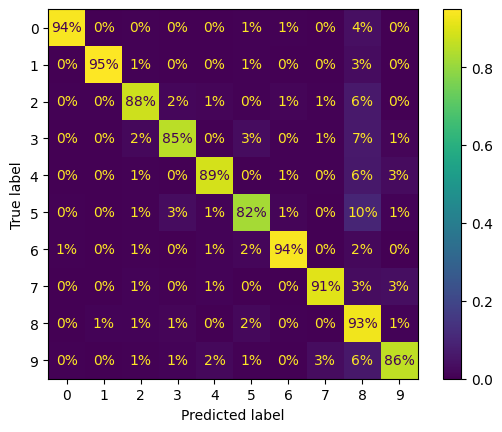

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize = 'true', values_format = '.0%')
plt.show()

It's now easier to understand that 82% of images of 5s were classified correctly; we can also spot that 10% of these 5s have been classified as 8s (but only 2% of the 8s have been classified as 5s); moreover, many digits have been misclassified as 8s. We can make this even clearer by only plotting the distribution of errors normalizing by row:

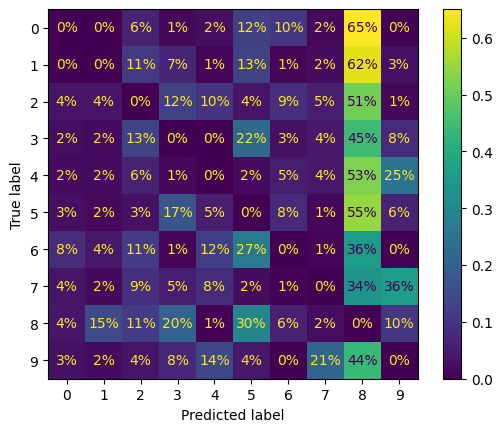

In [ ]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, 
                                        sample_weight=sample_weight,
                                        normalize="true",
                                        values_format=".0%")
plt.show()

(here the 55% in row #5 and column #8 means that the 55% of misclassified 5s have been classified as 8s, but it doesn't give us any insight about the absolute value of these misclassifications)

The column for class 8 is now really bright, confirming many images got misclassified as 8s.

We can also normalize by column putting *normalize = 'pred'*:

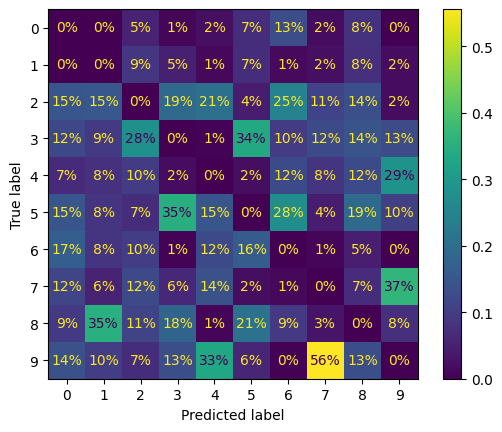

In [76]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, 
                                        sample_weight=sample_weight,
                                        normalize="pred",
                                        values_format=".0%")
plt.show()

(here, the 19% in row #5 and column #8 means that 19% of misclassified 5s are actually 8s)

Analyzing these confusion matrices can help get insights on how to improve the model; in this case, the effort should be spent on reducing the false 8s; possible solutions could be:
- get more training data for digits that look like 8s but are not 8s;
- engineer new features helping classifier (e.g., number of closed loops: 8 has two, 6 has one, 5 has none);
- preprocess the image to make some patterns stand out more (e.g., by using Scikit-Image, Pillow or OpenCV).

We can also analyze individual errors to gain more insight; for example, let's plot examples of 3s and 5s in a confusion matrix style:

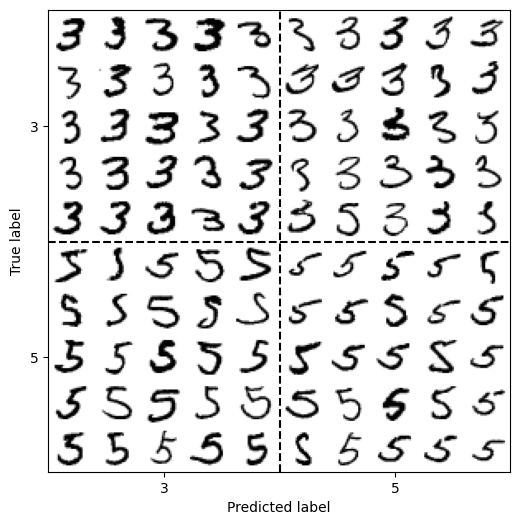

In [83]:
import numpy as np

def plot_confusion_image_grid(X_aa, X_ab, X_ba, X_bb, cl_a='3', cl_b='5', max_images=25):
    fig, ax = plt.subplots(figsize=(6,6))

    # limit images to max_images per cell
    X_aa = X_aa[:max_images]
    X_ab = X_ab[:max_images]
    X_ba = X_ba[:max_images]
    X_bb = X_bb[:max_images]

    # number of rows/cols for grid inside each cell
    def make_mosaic(X):
        if len(X) == 0:
            return np.ones((28, 28)) * 255  # empty white patch
        n = int(np.ceil(np.sqrt(len(X))))
        X = X[:n*n]
        return (X.reshape(n, n, 28, 28)
                 .swapaxes(1, 2)
                 .reshape(n*28, n*28))

    mosaics = [[make_mosaic(X_aa), make_mosaic(X_ab)],
               [make_mosaic(X_ba), make_mosaic(X_bb)]]

    # combine into big confusion matrix grid
    top = np.hstack(mosaics[0])
    bottom = np.hstack(mosaics[1])
    big_grid = np.vstack([top, bottom])

    ax.imshow(big_grid, cmap="binary")
    ax.set_xticks([big_grid.shape[1]//4, 3*big_grid.shape[1]//4], [cl_a, cl_b])
    ax.set_yticks([big_grid.shape[0]//4, 3*big_grid.shape[0]//4], [cl_a, cl_b])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    # draw separators
    ax.axhline(big_grid.shape[0]//2, color="k", linestyle="--")
    ax.axvline(big_grid.shape[1]//2, color="k", linestyle="--")

    plt.show()

cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]
plot_confusion_image_grid(X_aa, X_ab, X_ba, X_bb, cl_a='3', cl_b='5')


As we can see, some of the errors the model performs (bottom-left and top-right grids) are so badly written that even a human would have trouble classifying them; others are just obvious errors to us. Remember that the human brain is a fantastic pattern recognition system, so even if it seems an easy task for us, it may be not that simple.

Remember also that we used a simple *SGDClassifier* which is just a linear model assigning a weight per class to each pixel, summing up the weighted pixel intensities each time it sees a new image, in order to get a score for each class: 3s and 5s differ by only a few pixels, so it's easy for the model to confuse them.

To solve this, we could preprocess the images to ensure they are well centered and not too rotated; another possibility is **Data Augemntation**, a more sophisticated technique which creates variations of the training data by slightly shifting and rotating the images, making the model more tolerant to such variations. We will discuss this on Chapter 14.

## Multilabel Classification
A **Multilabel Classification** classifier is a classifier which needs to output more than one class per instance.

For example, suppose we need to build a face-recognition classifier which recognizes several people in the same picture; let's say it has been trained to recognize 3 faces: Alice, Bob and Charlie; if the picture shows Alice and Charlie it should output *\[True, False, True]*.

Let's look at an easier example; we will create an array containing 2 target labels for each digit image:
- first label indicates wheter or not the digit is large (>= 7);
- second label indicates wheter or not it is odd.

In [85]:
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

Then, we build a *KNeighborsClassifier* to predict these 2 labels (note how not all classifiers support multilabel classification):

In [86]:
knn_clf = KNeighborsClassifier()   
knn_clf.fit(X_train, y_multilabel)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


We can then make predictions:

In [87]:
knn_clf.predict([X[0]])

array([[False,  True]])

It gets it right; now, let's see how to evaluate a multilabel classifier; there are various ways, but one is to measure the $F_1$ score (or any other binary classifier metric we discussed) for each individual label and simply compute the average:

In [88]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average='macro')

0.9764102655606048

Note how this approach suppose that all labels are equally important.

If this isn't the case and, for example, we have many more pictures of Alice so we want to give more weight to the classifier's score on pictures of Alice, we can give to each label a weight equal to its **support** (i.e., number of instances with that target label), which can be done by putting *average = "weighted"* in the metric function:

In [89]:
f1_score(y_multilabel, y_train_knn_pred, average='weighted')

0.9778357403921755

We may also want to use a classifier which does not natively support multilabel classification, such as SVC; we have 2 possibilities to do so:
- train one model per label (this doesn't account for the dependencies between the 2 labels; for example a large digit is either 7, 8 or 9, so it is more likely to be odd than even, but the 2 classifiers won't interact each others);
- train a chain of models (in this way, when a model makes prediction, it used the input features plus all the prediction of the models before it); this can be done using the *ChainClassifier* class by sklearn.

Let's see how to implement the second approach:

In [90]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv = 3, random_state = 42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

,estimator,SVC()
,order,None
,cv,3
,chain_method,'predict'
,random_state,42
,verbose,False
,base_estimator,'deprecated'
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [91]:
chain_clf.predict([X[0]])

array([[0., 1.]])

Correct!

## Multioutput Classification
A **Multioutput Classification** task is a generalization of a **Multiclass Classification** task, in which each label can be multiclass (and not just binary).

As an example, we will build a system which removes noise from images: it takes a noisy digit image as input and it gives a clean digit image as output (images are represented as array of pixel intensities). We will have one label per pixel and the label can have multiple values (from 0 to 255).

(**NOTE**: in examples like this, the **line between classification and regression** is **very blurry**)

Let's start by adding random noise to the pixel intensities of the MNIST images:

In [92]:
np.random.seed(42)
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

Let's take a look at the first image:

Text(0.5, 1.0, 'Clean Output')

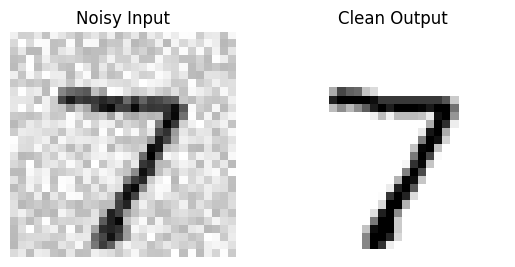

In [111]:
fig, ax = plt.subplots(1, 2)

ax[0].imshow(X_test_mod[0].reshape(28, 28), cmap='binary')
ax[0].axis('off')
ax[0].set_title('Noisy Input')

ax[1].imshow(y_test_mod[0].reshape(28, 28), cmap='binary')
ax[1].axis('off')
ax[1].set_title('Clean Output')

Let's now build a *KNeighborsClassifier*:

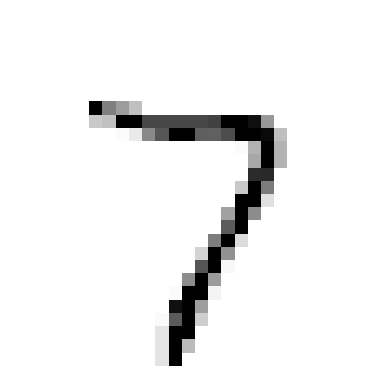

In [112]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()

We ended with an image which is close to the target!